# End-to-End: Detection → Tracking → Action Recognition

**Pipeline:**
1. **Detect** bees with YOLOv11-medium + SAHI sliced inference
2. **Track** bees across frames with ByteTracker → persistent track IDs
3. **Buffer** the last 16 DINOv2 feature vectors per tracked bee
4. **Classify** action with the Temporal Sequence Classifier once buffer is ready

**Models used:**
- Detection: `Trained_Models/DET_medium-best.pt`
- Action recognition: `Claude test/best_temporal_buf16.pt`

**Note:** DET_data_OG is the detection training set (images 6 frames apart).
Detection results will be strong; action labels are approximate for this dataset.
The temporal pipeline is designed for actual consecutive video frames.

In [1]:
import os
import cv2
import csv
import numpy as np
import torch
import torch.nn as nn
from collections import defaultdict, deque
from datetime import datetime
from transformers import AutoModel
from torchvision import transforms
from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import supervision as sv
import pandas as pd
from torch.amp.autocast_mode import autocast

print(f"supervision version: {sv.__version__}")
print("Imports OK")

supervision version: 0.27.0.post1
Imports OK


## Configuration

In [2]:
BASE_DIR = "D:/Projects/Masters"

# ── Model paths (absolute — avoids working-directory issues) ────────────────────
YOLO_PATH     = os.path.join(BASE_DIR, "Trained_Models/DET_medium-best.pt")
TEMPORAL_PATH = os.path.join(BASE_DIR, "ActionRecognition/best_temporal_buf16.pt")

# ── Data ────────────────────────────────────────────────────────────────────────
IMAGE_DIR  = os.path.join(BASE_DIR, "Data/AR_dataset/fanning/train/images")
OUTPUT_DIR = os.path.join(BASE_DIR, "ActionRecognition")
OUTPUT_CSV = os.path.join(OUTPUT_DIR, f"e2e_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv")

# ── Detection ───────────────────────────────────────────────────────────────────
DET_CONF       = 0.55   # YOLO confidence threshold
SAHI_SLICE     = 640    # SAHI tile size
SAHI_OVERLAP   = 0.35   # tile overlap
CROP_PAD       = 0.35   # padding factor around each bee crop

# ── Tracking ────────────────────────────────────────────────────────────────────
# ByteTracker: how long (frames) to keep a lost track alive before discarding it
TRACK_BUFFER   = 30

# ── Action recognition ──────────────────────────────────────────────────────────
BUFFER_SIZE    = 16     # frames in the rolling feature buffer (must match model)
MIN_BUFFER     = 4      # minimum frames before making a prediction (< BUFFER_SIZE → padded)
ACTION_CONF_TH = 0.55   # softmax probability below this → "uncertain"
ACTION_CLASSES = ["fanning", "neutral", "trophallaxis"]

# ── Display ─────────────────────────────────────────────────────────────────────
FPS            = 30     # playback speed
MAX_FRAMES     = None   # set to e.g. 200 to process only first N frames; None = all

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device      : {device}")
print(f"Image dir   : {IMAGE_DIR}")
print(f"YOLO model  : {YOLO_PATH}")
print(f"Temporal model: {TEMPORAL_PATH}")
print(f"Output CSV  : {OUTPUT_CSV}")

Device      : cuda
Image dir   : D:/Projects/Masters\Data/AR_dataset/fanning/train/images
YOLO model  : D:/Projects/Masters\Trained_Models/DET_medium-best.pt
Temporal model: D:/Projects/Masters\ActionRecognition/best_temporal_buf16.pt
Output CSV  : D:/Projects/Masters\ActionRecognition\e2e_results_20260426_102250.csv


## Model Definition
Must match the architecture used during training exactly.

In [3]:
class TemporalSequenceClassifier(nn.Module):
    """Identical to training definition — do not modify."""
    def __init__(self, feature_dim=384, num_classes=3, num_heads=4,
                 num_layers=2, dropout=0.3, max_seq_len=33):
        super().__init__()
        self.cls_token   = nn.Parameter(torch.randn(1, 1, feature_dim) * 0.02)
        self.pos_embed   = nn.Embedding(max_seq_len, feature_dim)
        encoder_layer    = nn.TransformerEncoderLayer(
            d_model=feature_dim, nhead=num_heads,
            dim_feedforward=feature_dim * 2,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm        = nn.LayerNorm(feature_dim)
        self.classifier  = nn.Sequential(
            nn.Linear(feature_dim, 128), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(128, num_classes),
        )

    def forward(self, x, padding_mask=None):
        B, T, _ = x.shape
        cls      = self.cls_token.expand(B, -1, -1)
        x        = torch.cat([cls, x], dim=1)
        pos      = torch.arange(T + 1, device=x.device).unsqueeze(0)
        x        = x + self.pos_embed(pos)
        if padding_mask is not None:
            cls_mask     = torch.zeros(B, 1, dtype=torch.bool, device=x.device)
            padding_mask = torch.cat([cls_mask, padding_mask], dim=1)
        x = self.transformer(x, src_key_padding_mask=padding_mask)
        return self.classifier(self.norm(x[:, 0]))

## Load Models

In [4]:
# ── 1. YOLO + SAHI ──────────────────────────────────────────────────────────────
yolo_model = YOLO(YOLO_PATH)
sahi_model = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model=yolo_model,
    confidence_threshold=DET_CONF,
    device=str(device),
)
print("YOLO + SAHI loaded")

# ── 2. DINOv2 feature extractor (frozen) ────────────────────────────────────────
dinov2 = AutoModel.from_pretrained("facebook/dinov2-small").to(device)
dinov2.eval()
for p in dinov2.parameters():
    p.requires_grad = False
print("DINOv2 loaded (frozen)")

# ── 3. Temporal sequence classifier ─────────────────────────────────────────────
ckpt = torch.load(TEMPORAL_PATH, map_location=device)
cfg  = ckpt["config"]
temporal_model = TemporalSequenceClassifier(
    feature_dim = cfg["feature_dim"],
    num_classes = cfg["num_classes"],
    num_heads   = cfg["num_heads"],
    num_layers  = cfg["num_layers"],
    dropout     = cfg["dropout"],
    max_seq_len = cfg["buffer_size"] + 1,
).to(device)
temporal_model.load_state_dict(ckpt["model_state"])
temporal_model.eval()
print(f"Temporal classifier loaded — trained to epoch {ckpt['epoch']}, Val F1: {ckpt['val_f1']:.4f}")
print(f"Buffer size: {cfg['buffer_size']} frames, Classes: {ACTION_CLASSES}")

YOLO + SAHI loaded
DINOv2 loaded (frozen)
Temporal classifier loaded — trained to epoch 9, Val F1: 0.9818
Buffer size: 16 frames, Classes: ['fanning', 'neutral', 'trophallaxis']


## Helper Functions

In [5]:
# ── Image preprocessing (same normalization as DINOv2 training) ─────────────────
_preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


def extract_crop(frame, xyxy, pad=CROP_PAD):
    """Crop a bee from the frame with proportional padding."""
    h, w  = frame.shape[:2]
    x1, y1, x2, y2 = map(int, xyxy)
    px    = int((x2 - x1) * pad)
    py    = int((y2 - y1) * pad)
    x1    = max(0, x1 - px)
    y1    = max(0, y1 - py)
    x2    = min(w, x2 + px)
    y2    = min(h, y2 + py)
    crop  = frame[y1:y2, x1:x2]
    return crop if crop.size > 0 else None


def get_dinov2_feature(crop_bgr):
    """BGR crop → DINOv2 CLS token [384] on CPU."""
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    tensor   = _preprocess(crop_rgb).unsqueeze(0).to(device)
    with torch.no_grad(), autocast(str(device)):
        out = dinov2(tensor)
        cls = out.last_hidden_state[:, 0]   # [1, 384]
    return cls.squeeze(0)   # [384], stays on GPU


def classify_buffer(feature_list):
    """
    Classify an action from a list of DINOv2 feature tensors.
    Returns (action_label, confidence).

    feature_list : list of Tensors [384], len between MIN_BUFFER and BUFFER_SIZE
    Short lists are padded to BUFFER_SIZE by repeating the last feature.
    """
    T    = BUFFER_SIZE
    N    = len(feature_list)
    feats, mask = [], []

    for i in range(T):
        if i < N:
            feats.append(feature_list[i])
            mask.append(False)
        else:
            feats.append(feature_list[-1])   # repeat last
            mask.append(True)                # mark as padding

    x    = torch.stack(feats).unsqueeze(0).to(device)             # [1, T, 384]
    pmask = torch.tensor(mask, dtype=torch.bool).unsqueeze(0).to(device)  # [1, T]

    with torch.no_grad(), autocast(str(device)):
        logits = temporal_model(x, padding_mask=pmask)    # [1, 3]
        probs  = torch.softmax(logits, dim=1)

    conf, idx = probs.max(dim=1)
    conf      = conf.item()
    label     = ACTION_CLASSES[idx.item()] if conf >= ACTION_CONF_TH else "uncertain"
    return label, conf


# ── Annotator colours per action ─────────────────────────────────────────────────
ACTION_COLORS = {
    "fanning"     : sv.Color(r=0,   g=220, b=100),   # green
    "trophallaxis": sv.Color(r=255, g=120, b=0),     # orange
    "neutral"     : sv.Color(r=100, g=180, b=255),   # blue
    "uncertain"   : sv.Color(r=220, g=0,   b=0),     # red
    "buffering"   : sv.Color(r=180, g=180, b=180),   # grey
}
DEFAULT_COLOR = sv.Color(r=180, g=180, b=180)

box_annotator   = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_thickness=1, text_scale=0.45)

print("Helpers ready")

Helpers ready


## Tracking Setup

ByteTracker assigns a persistent `track_id` to each bee across frames.
We maintain one rolling feature buffer per `track_id`.

In [6]:
try:
    # supervision >= 0.22
    tracker = sv.ByteTrack(
        track_activation_threshold=0.45,
        lost_track_buffer=TRACK_BUFFER,
        minimum_matching_threshold=0.8,
        frame_rate=FPS,
    )
except TypeError:
    # older supervision API
    tracker = sv.ByteTrack()

# track_id → deque of DINOv2 feature tensors (rolling buffer)
track_buffers = defaultdict(lambda: deque(maxlen=BUFFER_SIZE))

# track_id → last predicted (action, confidence) — persists until next prediction
track_actions = {}

print("ByteTracker ready")

ByteTracker ready


## Inference Loop

Press **ESC** to stop, **SPACE** to pause.

**Legend:**
- Green → fanning
- Orange → trophallaxis  
- Blue → neutral
- Red → uncertain (confidence below threshold)
- Grey → buffering (not enough frames yet)

Label format: `ID:N | action (conf%) | buf=K/16`

In [7]:
# ── Prepare image list ───────────────────────────────────────────────────────────
images = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(".jpg")])
if MAX_FRAMES is not None:
    images = images[:MAX_FRAMES]
print(f"Processing {len(images)} frames...")

# ── CSV output ───────────────────────────────────────────────────────────────────
with open(OUTPUT_CSV, "w", newline="") as f:
    csv.writer(f).writerow(
        ["frame_idx", "image_name", "track_id", "action", "action_conf",
         "det_conf", "buf_size", "x1", "y1", "x2", "y2"]
    )

delay = max(1, int(1000 / FPS))

for frame_idx, img_name in enumerate(images):
    img_path = os.path.join(IMAGE_DIR, img_name)
    frame    = cv2.imread(img_path)
    if frame is None:
        continue

    # ── 1. Detect (SAHI sliced) ──────────────────────────────────────────────────
    result = get_sliced_prediction(
        img_path, sahi_model,
        slice_height=SAHI_SLICE, slice_width=SAHI_SLICE,
        overlap_height_ratio=SAHI_OVERLAP, overlap_width_ratio=SAHI_OVERLAP,
        verbose=0,
    )

    if not result.object_prediction_list:
        cv2.imshow("Bee Detection + Action Recognition", frame)
        if cv2.waitKey(delay) == 27:
            break
        continue

    boxes       = np.array([p.bbox.to_xyxy() for p in result.object_prediction_list])
    det_confs   = np.array([p.score.value    for p in result.object_prediction_list])
    class_ids   = np.array([p.category.id    for p in result.object_prediction_list])

    detections  = sv.Detections(
        xyxy=boxes, confidence=det_confs, class_id=class_ids
    )

    # ── 2. Track ─────────────────────────────────────────────────────────────────
    detections  = tracker.update_with_detections(detections)

    if detections.tracker_id is None or len(detections) == 0:
        cv2.imshow("Bee Detection + Action Recognition", frame)
        if cv2.waitKey(delay) == 27:
            break
        continue

    # ── 3. Feature extraction + buffer update + classification ───────────────────
    labels_out  = []
    colors_out  = []

    for i, track_id in enumerate(detections.tracker_id):
        xyxy     = detections.xyxy[i]
        det_conf = detections.confidence[i]

        # Extract crop and DINOv2 feature
        crop = extract_crop(frame, xyxy)
        if crop is not None:
            feat = get_dinov2_feature(crop)          # [384] on GPU
            track_buffers[track_id].append(feat)

        buf_size = len(track_buffers[track_id])

        # Classify once we have enough frames
        if buf_size >= MIN_BUFFER:
            action, conf = classify_buffer(list(track_buffers[track_id]))
            track_actions[track_id] = (action, conf)
        elif track_id in track_actions:
            action, conf = track_actions[track_id]   # reuse last prediction
        else:
            action, conf = "buffering", 0.0          # not enough frames yet

        # Build label string
        if action == "buffering":
            label_str = f"ID:{track_id} | buffering ({buf_size}/{BUFFER_SIZE})"
        else:
            label_str = f"ID:{track_id} | {action} ({conf:.0%}) | buf={buf_size}"

        labels_out.append(label_str)
        colors_out.append(ACTION_COLORS.get(action, DEFAULT_COLOR))

        # Log to CSV
        x1, y1, x2, y2 = map(int, xyxy)
        with open(OUTPUT_CSV, "a", newline="") as f:
            csv.writer(f).writerow([
                frame_idx, img_name, track_id, action, f"{conf:.4f}",
                f"{det_conf:.4f}", buf_size, x1, y1, x2, y2
            ])

    # ── 4. Annotate ──────────────────────────────────────────────────────────────
    # Draw all boxes in their action colour
    annotated = frame.copy()
    for i, xyxy in enumerate(detections.xyxy):
        color = colors_out[i]
        x1, y1, x2, y2 = map(int, xyxy)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (color.r, color.g, color.b), 2)

    # Draw labels
    annotated = label_annotator.annotate(
        scene=annotated, detections=detections, labels=labels_out
    )

    # HUD
    n_tracked = len(detections)
    cv2.putText(annotated,
        f"Frame {frame_idx:04d}/{len(images)} | {img_name} | Tracked: {n_tracked}",
        (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    cv2.imshow("Bee Detection + Action Recognition", annotated)

    key = cv2.waitKey(delay)
    if key == 27:    # ESC
        break
    elif key == 32:  # SPACE — pause until any key
        cv2.waitKey(0)

cv2.destroyAllWindows()
print(f"Done. Results saved to:\n  {OUTPUT_CSV}")

Processing 14400 frames...
Done. Results saved to:
  D:/Projects/Masters\ActionRecognition\e2e_results_20260426_102250.csv


## Results Summary

Total detections logged : 4,666
Unique tracks           : 381
Frames with detections  : 500

Action distribution:
action
fanning         2134
neutral         1417
buffering        940
uncertain        105
trophallaxis      70

Mean confidence per action:
action
fanning         0.940
neutral         0.911
trophallaxis    0.866
uncertain       0.515


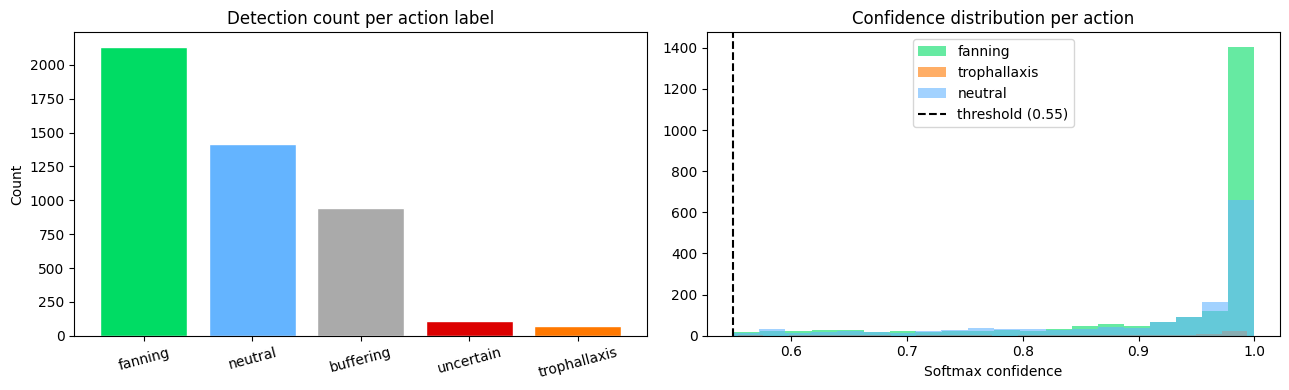


Sample rows:
 frame_idx          image_name  track_id    action  action_conf  det_conf  buf_size   x1  y1   x2  y2
         0 20230609c_00228.jpg         1 buffering       0.0000    0.9292         1  830 394  887 481
         0 20230609c_00228.jpg         2 buffering       0.0000    0.9286         1 1109 730 1185 822
         0 20230609c_00228.jpg         3 buffering       0.0000    0.9272         1  505 372  579 427
         0 20230609c_00228.jpg         4 buffering       0.0000    0.9169         1  793 860  853 920
         0 20230609c_00228.jpg         5 buffering       0.0000    0.9021         1   98 689  165 759
         0 20230609c_00228.jpg         6 buffering       0.0000    0.8984         1 1760 670 1830 739
         1 20230609c_00229.jpg         3 buffering       0.0000    0.9276         2  502 371  573 422
         2 20230609c_00230.jpg         3 buffering       0.0000    0.8957         3  505 370  577 418
         3 20230609c_00231.jpg        12 buffering       0.0000    0

In [23]:
import matplotlib.pyplot as plt

df = pd.read_csv(OUTPUT_CSV)
print(f"Total detections logged : {len(df):,}")
print(f"Unique tracks           : {df['track_id'].nunique()}")
print(f"Frames with detections  : {df['frame_idx'].nunique()}")

print("\nAction distribution:")
print(df["action"].value_counts().to_string())

print("\nMean confidence per action:")
classified = df[df["action"] != "buffering"]
print(classified.groupby("action")["action_conf"].mean().round(3).to_string())

# ── Action distribution bar chart ────────────────────────────────────────────────
counts = df["action"].value_counts()
colors = {"fanning": "#00dc64", "trophallaxis": "#ff7800",
          "neutral": "#64b4ff", "uncertain": "#dc0000", "buffering": "#aaaaaa"}
bar_colors = [colors.get(a, "#888888") for a in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(counts.index, counts.values, color=bar_colors, edgecolor="white")
axes[0].set_title("Detection count per action label")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=15)

# ── Confidence histogram ──────────────────────────────────────────────────────────
for action in ["fanning", "trophallaxis", "neutral"]:
    sub = classified[classified["action"] == action]["action_conf"]
    if len(sub):
        axes[1].hist(sub, bins=20, alpha=0.6,
                     label=action, color=colors.get(action, "grey"))
axes[1].axvline(x=ACTION_CONF_TH, color="black", linestyle="--",
                label=f"threshold ({ACTION_CONF_TH})")
axes[1].set_title("Confidence distribution per action")
axes[1].set_xlabel("Softmax confidence")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "e2e_summary.png"), dpi=150)
plt.show()

print("\nSample rows:")
print(df.head(10).to_string(index=False))